In [4]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import glob
from pathlib import Path

SW_PATH       = Path("/data/archive/sgp/sgpqcrad1longE13.c2/")
LASSO_ROOT    = Path("/data/project/ARM_Summer_School_2026/data/modeling/lasso")
DPSCREAM_ROOT = Path("/data/project/ARM_Summer_School_2026/data/modeling/dpscream")

CASE_DAYS  = ["20180709", "20190517", "20190929"]
SIM_IDS    = {"20180709": "8", "20190517": "4", "20190929": "5"}
UTC_OFFSET = pd.Timedelta(hours=6)   # SGP is UTC-6

In [5]:
def load_wrf_raw(date_str: str) -> xr.DataArray:
    """Load LASSO WRF domain-mean SWDNB with Time coord in local time (UTC-6)."""
    sid = SIM_IDS[date_str]
    yr, mon = date_str[:4], date_str[4:6]
    pattern = str(LASSO_ROOT / date_str / f"sgplassodiagraw{sid}C1.m1" / "raw_model"
                  / f"wrfout_d01_{yr}-{mon}-*.nc")
    ds    = xr.open_mfdataset(pattern, combine='nested', concat_dim='Time')
    times = (pd.to_datetime([bytes(t).decode().replace("_", "T") for t in ds["Times"].values])
             - UTC_OFFSET)
    return ds.assign_coords(Time=times).mean(['south_north', 'west_east'])

In [6]:
ds_wrf = [load_wrf_raw(d) for d in CASE_DAYS]

In [8]:
ds_wrf[0]

<xarray.Dataset> Size: 52MB
Dimensions:                (Time: 91, bottom_top: 226, bottom_top_stag: 227,
                            soil_layers_stag: 5, west_east_stag: 251,
                            south_north_stag: 251, force_layers: 751)
Coordinates:
    XTIME                  (Time) datetime64[ns] 728B dask.array<chunksize=(6,), meta=np.ndarray>
  * Time                   (Time) datetime64[ns] 728B 2018-07-09T06:00:00 ......
Dimensions without coordinates: bottom_top, bottom_top_stag, soil_layers_stag,
                                west_east_stag, south_north_stag, force_layers
Data variables: (12/251)
    Times                  (Time) |S19 2kB dask.array<chunksize=(1,), meta=np.ndarray>
    LU_INDEX               (Time) float32 364B dask.array<chunksize=(1,), meta=np.ndarray>
    ZNU                    (Time, bottom_top) float32 82kB dask.array<chunksize=(1, 226), meta=np.ndarray>
    ZNW                    (Time, bottom_top_stag) float32 83kB dask.array<chunksize=(1, 227), meta=np.ndarray>
    ZS                     (Time, soil_layers_stag) float32 2kB dask.array<chunksize=(1, 5), meta=np.ndarray>
    DZS                    (Time, soil_layers_stag) float32 2kB dask.array<chunksize=(1, 5), meta=np.ndarray>
    ...                     ...
    SMAXACT                (Time, bottom_top) float32 82kB dask.array<chunksize=(1, 226), meta=np.ndarray>
    RMINACT                (Time, bottom_top) float32 82kB dask.array<chunksize=(1, 226), meta=np.ndarray>
    LANDMASK               (Time) float32 364B dask.array<chunksize=(1,), meta=np.ndarray>
    LAKEMASK               (Time) float32 364B dask.array<chunksize=(1,), meta=np.ndarray>
    SST                    (Time) float32 364B dask.array<chunksize=(1,), meta=np.ndarray>
    SST_INPUT              (Time) float32 364B dask.array<chunksize=(1,), meta=np.ndarray>

# Long's surface downward SW Rad

As suggested by Bill:

> If you would like to cross compare surface downwelling shortwave radiation, a good obs dataset to use is the qcradlong product (Long is a person's name and not just longwave radiation :slightly_smiling_face: ). You can find this data in the archive folder mounted to the jupyter server.

> QCRAD surface radiation product: /data/project/sgpqcrad1longE13.c2
Example file = sgpqcrad1longE13.c2.20180709.000000.cdf

> Note, I had trouble opening the file directly in xarray. If I first opened it with the netCDF4 library, then xarray worked. Don't know why...

In [2]:
def load_sw_obs(date_str: str, resample: str) -> xr.DataArray:
    """Load QCRAD SW obs for one case day, resampled to resample freq.

    resample: '1h' for DPSCREAM comparison, '10min' for LASSO comparison.
    Returns DataArray with time in local time (UTC-6).
    Note: opens current day + next day to cover runs that extend past midnight UTC.
    """
    d = int(date_str)
    files = [str(SW_PATH / f"sgpqcrad1longE13.c2.{d}.000000.cdf"),
             str(SW_PATH / f"sgpqcrad1longE13.c2.{d+1}.000000.cdf")]
    sw = xr.open_mfdataset(files).BestEstimate_down_short_hemisp
    t_start = 13 * 60 if resample == '1h' else 12 * 60   # DPSCREAM starts 13 UTC, LASSO 12 UTC
    sw = sw.isel(time=slice(t_start, (24 + 3 + 1) * 60)).resample(time=resample).mean()
    return sw.assign_coords(time=sw.time - UTC_OFFSET)


def load_wrf_swdnb(date_str: str) -> xr.DataArray:
    """Load LASSO WRF domain-mean SWDNB with Time coord in local time (UTC-6)."""
    sid = SIM_IDS[date_str]
    yr, mon = date_str[:4], date_str[4:6]
    pattern = str(LASSO_ROOT / date_str / f"sgplassodiagraw{sid}C1.m1" / "raw_model"
                  / f"wrfout_d01_{yr}-{mon}-*.nc")
    ds    = xr.open_mfdataset(pattern, combine='nested', concat_dim='Time')
    times = (pd.to_datetime([bytes(t).decode().replace("_", "T") for t in ds["Times"].values])
             - UTC_OFFSET)
    return ds.assign_coords(Time=times).mean(['south_north', 'west_east'])

In [3]:
sw_obs_dpscream = xr.concat([load_sw_obs(d, '1h')    for d in CASE_DAYS], dim='case')
sw_obs_lasso    = xr.concat([load_sw_obs(d, '10min') for d in CASE_DAYS], dim='case')
wrf_swdnb       = [load_wrf_swdnb(d) for d in CASE_DAYS]

# DPSCREAM: sorted glob ensures date=0,1,2 matches CASE_DAYS order
dpscream_files = sorted(glob.glob(
    str(DPSCREAM_ROOT / "scream_dpxx_LASSO_SGP_*.fullfield.AVERAGE.nhours_x1.*.nc")))
ds_dpscream = xr.open_mfdataset(dpscream_files, combine='nested', concat_dim='date')
ds_dpscream = ds_dpscream.assign_coords(time=ds_dpscream.time - UTC_OFFSET)

print(f"Obs DPSCREAM: {sw_obs_dpscream.dims}  {sw_obs_dpscream.shape}")
print(f"Obs LASSO:    {sw_obs_lasso.dims}  {sw_obs_lasso.shape}")
print(f"WRF loaded:   {len(wrf_swdnb)} days")
print(f"DPSCREAM files ({len(dpscream_files)}): {[Path(f).name for f in dpscream_files]}")

ERROR 1: PROJ: proj_create_from_database: Open of /opt/conda/share/proj failed


Obs DPSCREAM: ('case', 'time')  (3, 45)
Obs LASSO:    ('case', 'time')  (3, 288)
WRF loaded:   3 days
DPSCREAM files (3): ['scream_dpxx_LASSO_SGP_2018-07-09.fullfield.AVERAGE.nhours_x1.2018-07-09-43200.nc', 'scream_dpxx_LASSO_SGP_2019-05-17.fullfield.AVERAGE.nhours_x1.2019-05-17-43200.nc', 'scream_dpxx_LASSO_SGP_2019-09-29.fullfield.AVERAGE.nhours_x1.2019-09-29-43200.nc']


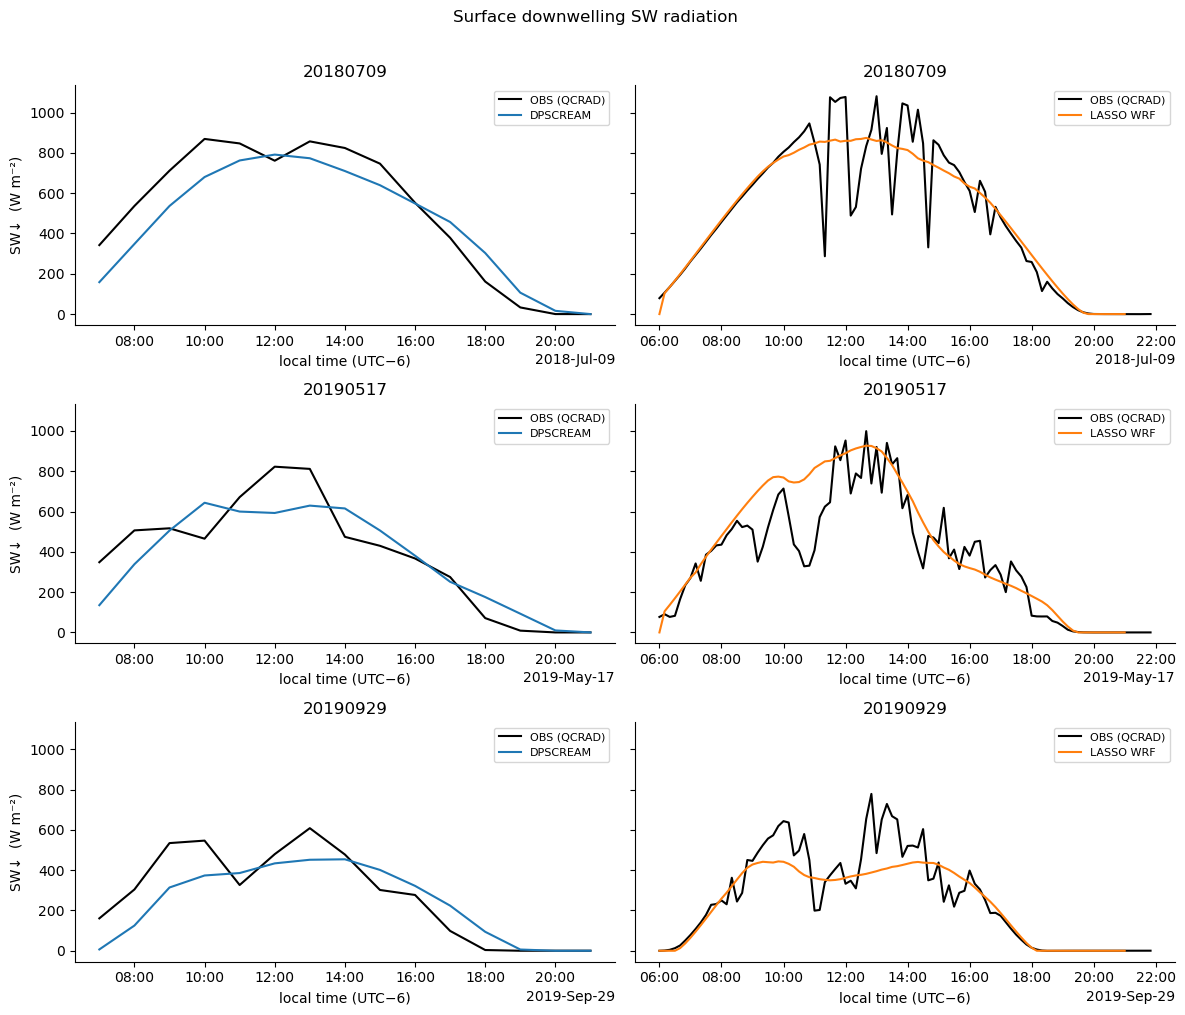

In [26]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharey=True)

for i, day in enumerate(CASE_DAYS):
    # --- left: DPSCREAM vs OBS ---
    ax = axes[i, 0]
    sw_obs_dpscream.isel(case=i).plot(ax=ax, color="k",         label="OBS (QCRAD)")
    ds_dpscream["SW_flux_dn_at_model_bot"].isel(date=i).mean("ncol").plot(
        ax=ax, color="tab:blue", label="DPSCREAM")
    ax.set_title(f"{day}")
    ax.set_xlabel("local time (UTC−6)")
    ax.set_ylabel("SW↓  (W m⁻²)")
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

    # --- right: LASSO WRF vs OBS ---
    ax = axes[i, 1]
    sw_obs_lasso.isel(case=i).plot(ax=ax, color="k",           label="OBS (QCRAD)")
    wrf_swdnb[i].plot(          ax=ax, color="tab:orange",     label="LASSO WRF")
    ax.set_title(f"{day}")
    ax.set_xlabel("local time (UTC−6)")
    ax.set_ylabel("")
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Surface downwelling SW radiation", y=1.01)
plt.tight_layout()
plt.show()